In [2]:
import algorithms.SCoNE as SCoNE
import algorithms.MVBCWrapper as MVBCWrapper
import algorithms.RGWASWrapper as RGWASWrapper
import importlib
importlib.reload(SCoNE)
import pandas as pd
import evaluation.cluster_evaluation as cluster_evaluation
from itertools import product
import submitit
import os
from concurrent.futures import ProcessPoolExecutor

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

# make tmp dir
root_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno'
tmp_folder = f"{root_dir}/output/tmp"
os.makedirs(tmp_folder, exist_ok=True)

# Code to simulate data

In [3]:
import numpy as np

def proj_nonneg(x):
    # If already feasible, return x as-is (avoids an allocation most iterations)
    if x.min() >= 0:
        return x
    return np.maximum(x, 0)

def make_correlated_matrices(m, r, rho, seed=1):
    rng = np.random.default_rng(seed)
    Z = proj_nonneg(rng.normal(size=(m, r)))
    E = proj_nonneg(rng.normal(size=(m, r)))
    W1 = Z
    W2 = rho * Z + np.sqrt(1 - rho**2) * E
    if rho==1:
        assert np.allclose(W1, W2)
    return W1, W2

def simulate_views(n=2500, num_genes=100, M_C=100, M_Z=5, rank=3, seed=0, ZU_weight=1, noise=0, sparsity=0, rho=1):
    """
    G:  n x num_genes  (Poisson with rate WH_g.T + ZU_g.T)
    C:  n x M_C  (Poisson with rate WH_c.T + ZU_c.T)

    Z: n x M_Z covariates (non-negative random numbers)

      W   : n x rank
      H_g : num_genes x rank
      U_g : M_Z x num_genes
      H_c: n x M_C
      U_c: M_Z x M_C
    """
    rng = np.random.default_rng(seed)

    # 1. Sample factor matrices
    # Sample nonnegative factors so Poisson rates are valid
    W_C, W_G = make_correlated_matrices(n, rank, rho,seed=seed+1)
    H_C = proj_nonneg(rng.normal(size=(M_C, rank)))
    # generate linked markers
    H_G = proj_nonneg(rng.normal(size=(num_genes, rank)))
    # generate superpop shift for each feature
    U_C = proj_nonneg(rng.normal(size=(M_C, M_Z)))
    U_G =  proj_nonneg(rng.normal(size=(num_genes, M_Z)))
    # generate 5 superpopulations
    superpops = rng.permutation(n) % M_Z   
    Z = (superpops[:, None] == np.arange(M_Z)).astype(int) 

    #2. impose sparsity (P(W_ij=0)=sparsity)
    mask = np.random.rand(*(n,rank)) > sparsity
    W_C = W_C * mask
    W_G = W_G * mask
    avg_corr = np.mean([np.corrcoef(W_C[:,k], W_G[:,k])[0,1]
                    for k in range(W_C.shape[1])])

    
    # Means
    M_c = W_C@H_C.T + (ZU_weight)*Z@U_C.T + (noise)*proj_nonneg(rng.normal(size=(n, M_C)))
    M_g = W_G@H_G.T + (ZU_weight)*Z@U_G.T + (noise)*proj_nonneg(rng.normal(size=(n, num_genes)))

    # Generate the two observed matrices
    G = rng.poisson(M_g)  
    C = rng.poisson(M_c)          

    return {"G": G, "C": C, "Z":Z, "W_C": W_C, "W_G":W_G, "H_G": H_G, "H_C": H_C, "U_G": U_G, "U_C": U_C}

sim = simulate_views(n=200,M_C=50,num_genes=50,M_Z=5,rank=3,seed=0,ZU_weight=1,noise=0,sparsity=0)

# Code to evaluate reconstruction

In [4]:
from scipy.optimize import linear_sum_assignment


def frobenius_cosine_similarity(A, B):
    num = np.trace(A.T @ B)
    den = np.sqrt(np.trace(A.T @ A)) * np.sqrt(np.trace(B.T @ B))
    return num / den

def best_permutation_similarity(W_true, W_hat):
    # Compute pairwise column inner products (the numerator terms)
    M = W_true.T @ W_hat 
    row_ind, col_ind = linear_sum_assignment(-M) # maximize numerator
    W_hat_perm = W_hat[:, col_ind] # optimal permutation
    return frobenius_cosine_similarity(W_true, W_hat_perm)


# Code to run all comparison methods (and parallelize)

In [96]:
def _call_kwargs(kw):
    return run_one_wrapper(**kw)  # expands kwargs dict

def run_one_wrapper(run_name,G,C,Z,lambda_W,lambda_H_G,lambda_H_C,lambda_Gloss,G_loss_type,C_loss_type,
                    G_path,C_path,Z_path,sim,variable_name,variable,rank=3,init_name=1):
    results = []
    results_columns = ['run_name','factor_matrix','init','sim','total_loss']
    # simulate data
    if run_name in ['G-NMF','C-NMF','G-CoNE','C-CoNE','HNMF','CoNE','SCoNE','SCoNE(Fro)','sHNMF','CoNE(Fro)']:
        algorithm_func_kwargs={"G":G, "C":C, "Z":Z,"rank":rank, "num_init":1,
                        "lambda_W":lambda_W, "lambda_H_G":lambda_H_G, "lambda_H_C":lambda_H_C,"lambda_Gloss":lambda_Gloss,
                        "max_inner":50, "rho":0.1, "sigma":1e-4, "inner_ftol":1e-4,
                        "G_loss_type":G_loss_type, "C_loss_type": C_loss_type,
                        "max_outer":100, "min_outer":5, "tol":1e-6}
        factor_matrices, loss_function = SCoNE.alternating_opt(**algorithm_func_kwargs)
        total_loss = loss_function['total_loss'][-1]
    elif run_name == 'MVBC':
        algorithm_func_kwargs = {"G_path":G_path,"C_path":C_path, "rank":rank,
                    "lambda_W":lambda_W, "lambda_H_G":lambda_H_G, "lambda_H_C":lambda_H_C, "r_path":'/gpfs/commons/home/anewbury/miniconda/bin/Rscript'}
        factor_matrices, loss_function = MVBCWrapper.MVBCWrapper(**algorithm_func_kwargs)
        if factor_matrices is False: # run failed for reasons specified in MVBCWrapper
            return pd.DataFrame() 
        total_loss = loss_function['total_loss'][-1]
    elif run_name == 'RGWAS':
        algorithm_func_kwargs = {"r_path":'/gpfs/commons/home/anewbury/miniconda/bin/Rscript', "G_path":G_path,
                        "C_path":C_path, "Z_path":Z_path, "num_init":1,"rank":rank}
        factor_matrices, loss_function = RGWASWrapper.RGWASWrapper(**algorithm_func_kwargs)
        if factor_matrices is False: # run failed for reasons specified in RGWASWrapper
            return pd.DataFrame() 
        total_loss = -loss_function['ll'][-1]
    else: assert True == False, f"invalid run name {run_name}"
    for k,v in factor_matrices.items():
        if k=="W":
            results.append([run_name,"W_C",init_name,best_permutation_similarity(sim["W_C"],v),total_loss])
            results.append([run_name,"W_G",init_name,best_permutation_similarity(sim["W_G"],v),total_loss])
        else:
            results.append([run_name,k,init_name,best_permutation_similarity(sim[k],v),total_loss])
    results = pd.DataFrame(results,columns=results_columns)
    results[variable_name] = variable
    results['lambda_W'] = lambda_W
    results['lambda_H_G'] = lambda_H_G
    results['lambda_H_C'] = lambda_H_C
    return results

In [ ]:
from plotnine import *
def run_one(variable_name, variable_range):
    testing_runs = ['RGWAS']# TODO: ['G-NMF','C-NMF','G-CoNE','C-CoNE','HNMF','CoNE','SCoNE','SCoNE(Fro)','RGWAS','MVBC']
    tuning_runs = ['SCoNE','SCoNE(Fro)','MVBC']
    all_testing_results = []
    for variable in variable_range:
        # SIMUALTE DATA 
        sim_kwargs = {"n":500,"M_C":50,"num_genes":50,variable_name:variable,"seed":0} 
        sim = simulate_views(**sim_kwargs) 
        # write G,C,Z to paths
        np.save(f'{tmp_folder}/G_{variable_name}_{variable}',sim["G"])
        np.save(f'{tmp_folder}/C_{variable_name}_{variable}',sim["C"])
        np.save(f'{tmp_folder}/Z_{variable_name}_{variable}',sim["Z"])
        # TUNING
        lambda_options = [1e-4,1e-3,1e-2,1,10,100,1000] 
        lambda_combos = product(lambda_options,lambda_options,lambda_options)
        cfgs = []
        for init in range(10):
            for lambda_W, lambda_H_G, lambda_H_C in lambda_combos:
                for run_name in tuning_runs:
                    algorithm_kwargs = {"run_name":run_name,"G":sim["G"] if not 'C-' in run_name else None,
                                    "C":sim["C"] if not 'G-' in run_name else None,
                                    "Z":sim["Z"] if not 'NMF' in run_name else np.zeros((sim["Z"].shape[0],sim["Z"].shape[1])),
                                    "lambda_W":lambda_W,"lambda_H_G":lambda_H_G,"lambda_H_C":lambda_H_C,"lambda_Gloss":1,
                                    "G_loss_type":None if 'C-' in run_name else('fro' if 'Fro' in run_name else 'kl_div'),
                                    "C_loss_type":None if 'G-' in run_name else('fro' if 'Fro' in run_name else 'kl_div'),
                                    "sim":sim,"rank":3,"init_name":init,
                                    "G_path":f'{tmp_folder}/G_{variable_name}_{variable}.npy',
                                    "C_path":f'{tmp_folder}/C_{variable_name}_{variable}.npy',
                                    "Z_path":f'{tmp_folder}/Z_{variable_name}_{variable}.npy',"variable_name":variable_name,"variable":variable}
                    _call_kwargs(algorithm_kwargs) # TODO: remove
                    cfgs.append(algorithm_kwargs)
        with ProcessPoolExecutor() as pool:
            results_list = list(pool.map(_call_kwargs, cfgs))
        tuning_results = pd.concat(results_list, ignore_index=True)

        idx = tuning_results.groupby(['run_name'])["total_loss"].idxmin()
        best = (
            tuning_results.loc[idx, tuning_results.columns]
            .reset_index(drop=True)
        )
        
    
        # testing set
        sim_kwargs = {"n":500,"M_C":50,"num_genes":50,variable_name:variable,"seed":1} 
        sim = simulate_views(**sim_kwargs) 
        # write G,C,Z to paths
        np.save(f'{tmp_folder}/G_{variable_name}_{variable}',sim["G"])
        np.save(f'{tmp_folder}/C_{variable_name}_{variable}',sim["C"])
        np.save(f'{tmp_folder}/Z_{variable_name}_{variable}',sim["Z"])
        cfgs = []
        for init in range(10):
            for run_name in testing_runs:
                if run_name in tuning_runs:
                    assert best[(best['run_name']==run_name)].shape[0] == 1
                    lambda_W, lambda_H_G, lambda_H_C = best[(best['run_name']==run_name)][['lambda_W','lambda_H_G','lambda_H_C']].values[0].tolist()
                else:
                    lambda_W, lambda_H_G, lambda_H_C = (0,0,0)
                algorithm_kwargs = {"run_name":run_name,"G":sim["G"] if not 'C-' in run_name else None,
                                "C":sim["C"] if not 'G-' in run_name else None,
                                "Z":sim["Z"] if not 'NMF' in run_name else np.zeros((sim["Z"].shape[0],sim["Z"].shape[1])),
                                "lambda_W":lambda_W,"lambda_H_G":lambda_H_G,"lambda_H_C":lambda_H_C,"lambda_Gloss":1,
                                "G_loss_type":None if 'C-' in run_name else('fro' if 'Fro' in run_name else 'kl_div'),
                                "C_loss_type":None if 'G-' in run_name else('fro' if 'Fro' in run_name else 'kl_div'),
                                "sim":sim,"rank":3,"init_name":init,
                                "G_path":f'{tmp_folder}/G_{variable_name}_{variable}.npy',
                                "C_path":f'{tmp_folder}/C_{variable_name}_{variable}.npy',
                                "Z_path":f'{tmp_folder}/Z_{variable_name}_{variable}.npy',"variable_name":variable_name,"variable":variable}
                cfgs.append(algorithm_kwargs)
        with ProcessPoolExecutor() as pool:
            results_list = list(pool.map(_call_kwargs, cfgs))
        testing_results = pd.concat(results_list, ignore_index=True)
        all_testing_results.append(testing_results)


    all_testing_results = pd.concat(all_testing_results)
    summary = (
        all_testing_results.groupby(["run_name", "factor_matrix", variable_name])["sim"]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]

    return summary

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [90]:
import importlib
importlib.reload(RGWASWrapper)

<module 'algorithms.RGWASWrapper' from '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code/algorithms/RGWASWrapper.py'>

In [97]:
summary = run_one("rho", [0.1])

KeyboardInterrupt: 

In [ ]:
summary = run_one("rho", np.arange(0,1.1,0.1))


In [102]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary.csv',index_col=0)

In [ ]:
# remove values that aren't applicably
summary = summary[~(((summary['run_name'].str.startswith('C-'))&(summary['factor_matrix'].str.contains('G')))|
          ((summary['run_name'].str.startswith('G-'))&(summary['factor_matrix'].str.contains('C'))))].copy()

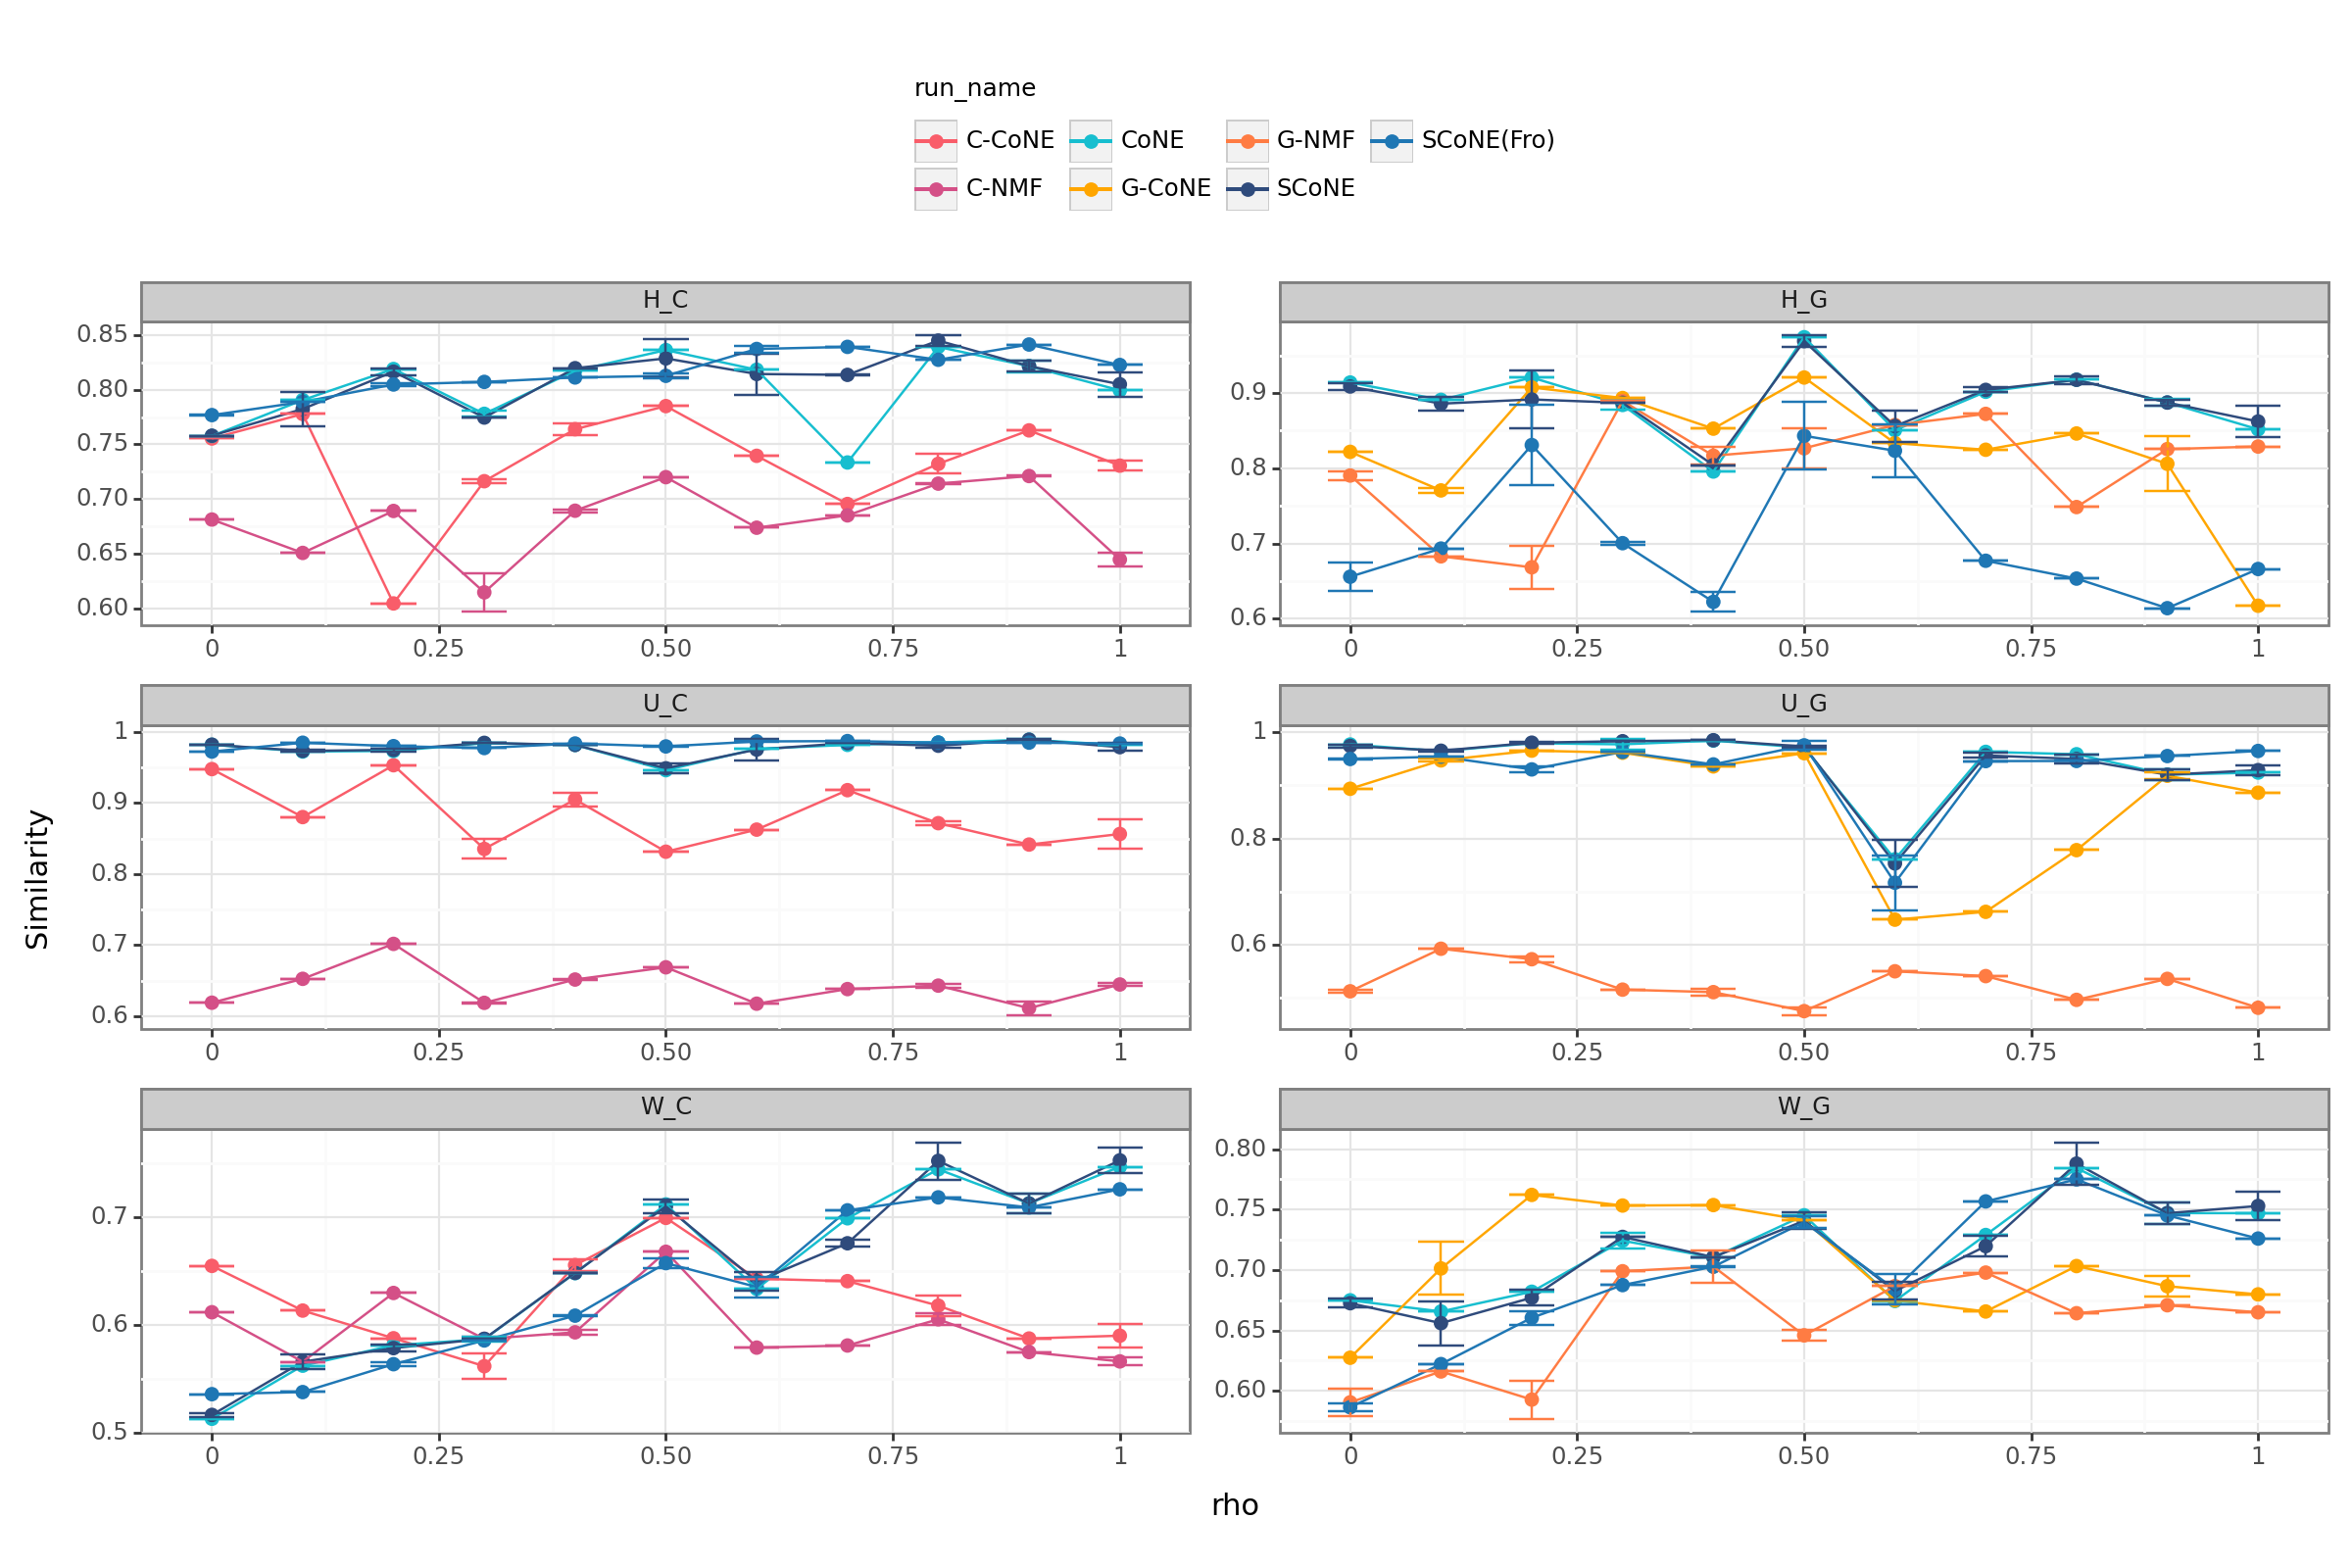

In [110]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)'])], aes("rho", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x="rho")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

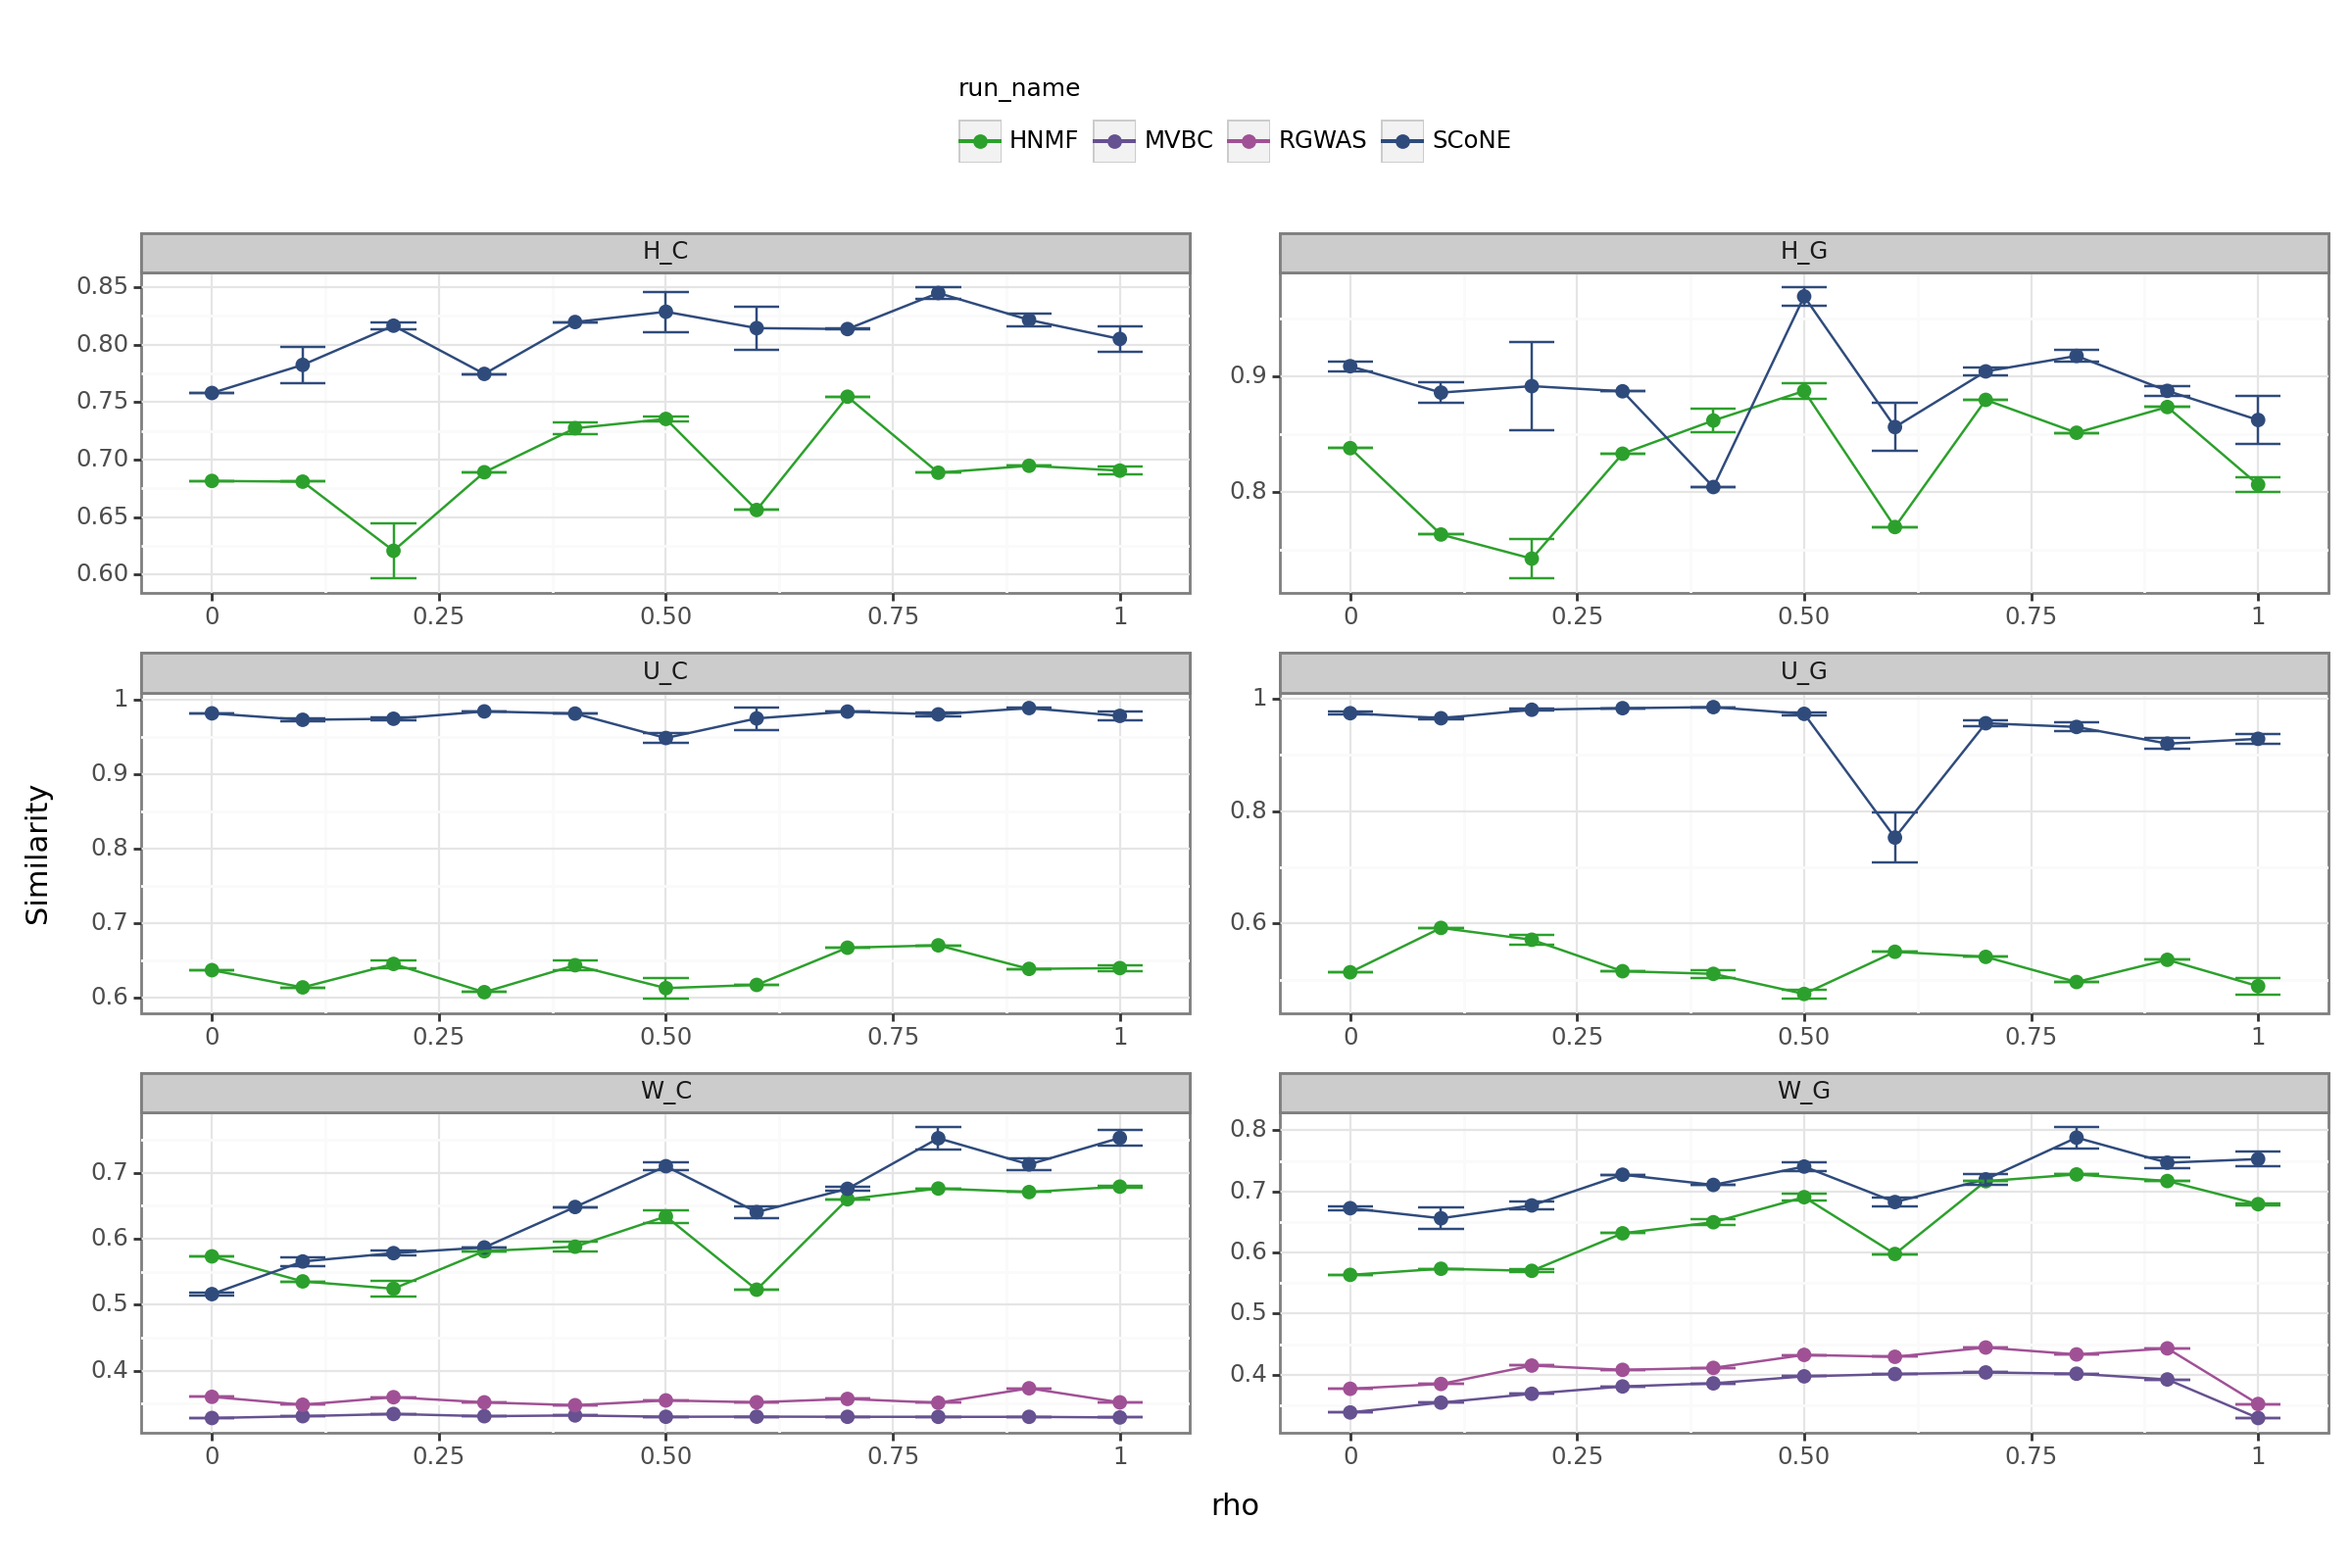

In [111]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes("rho", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x="rho")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

# Assess runs over ZU weight

In [ ]:
summary = run_one("ZU_weight", [0,0.25,0.5,0.75,1,1.5,2])


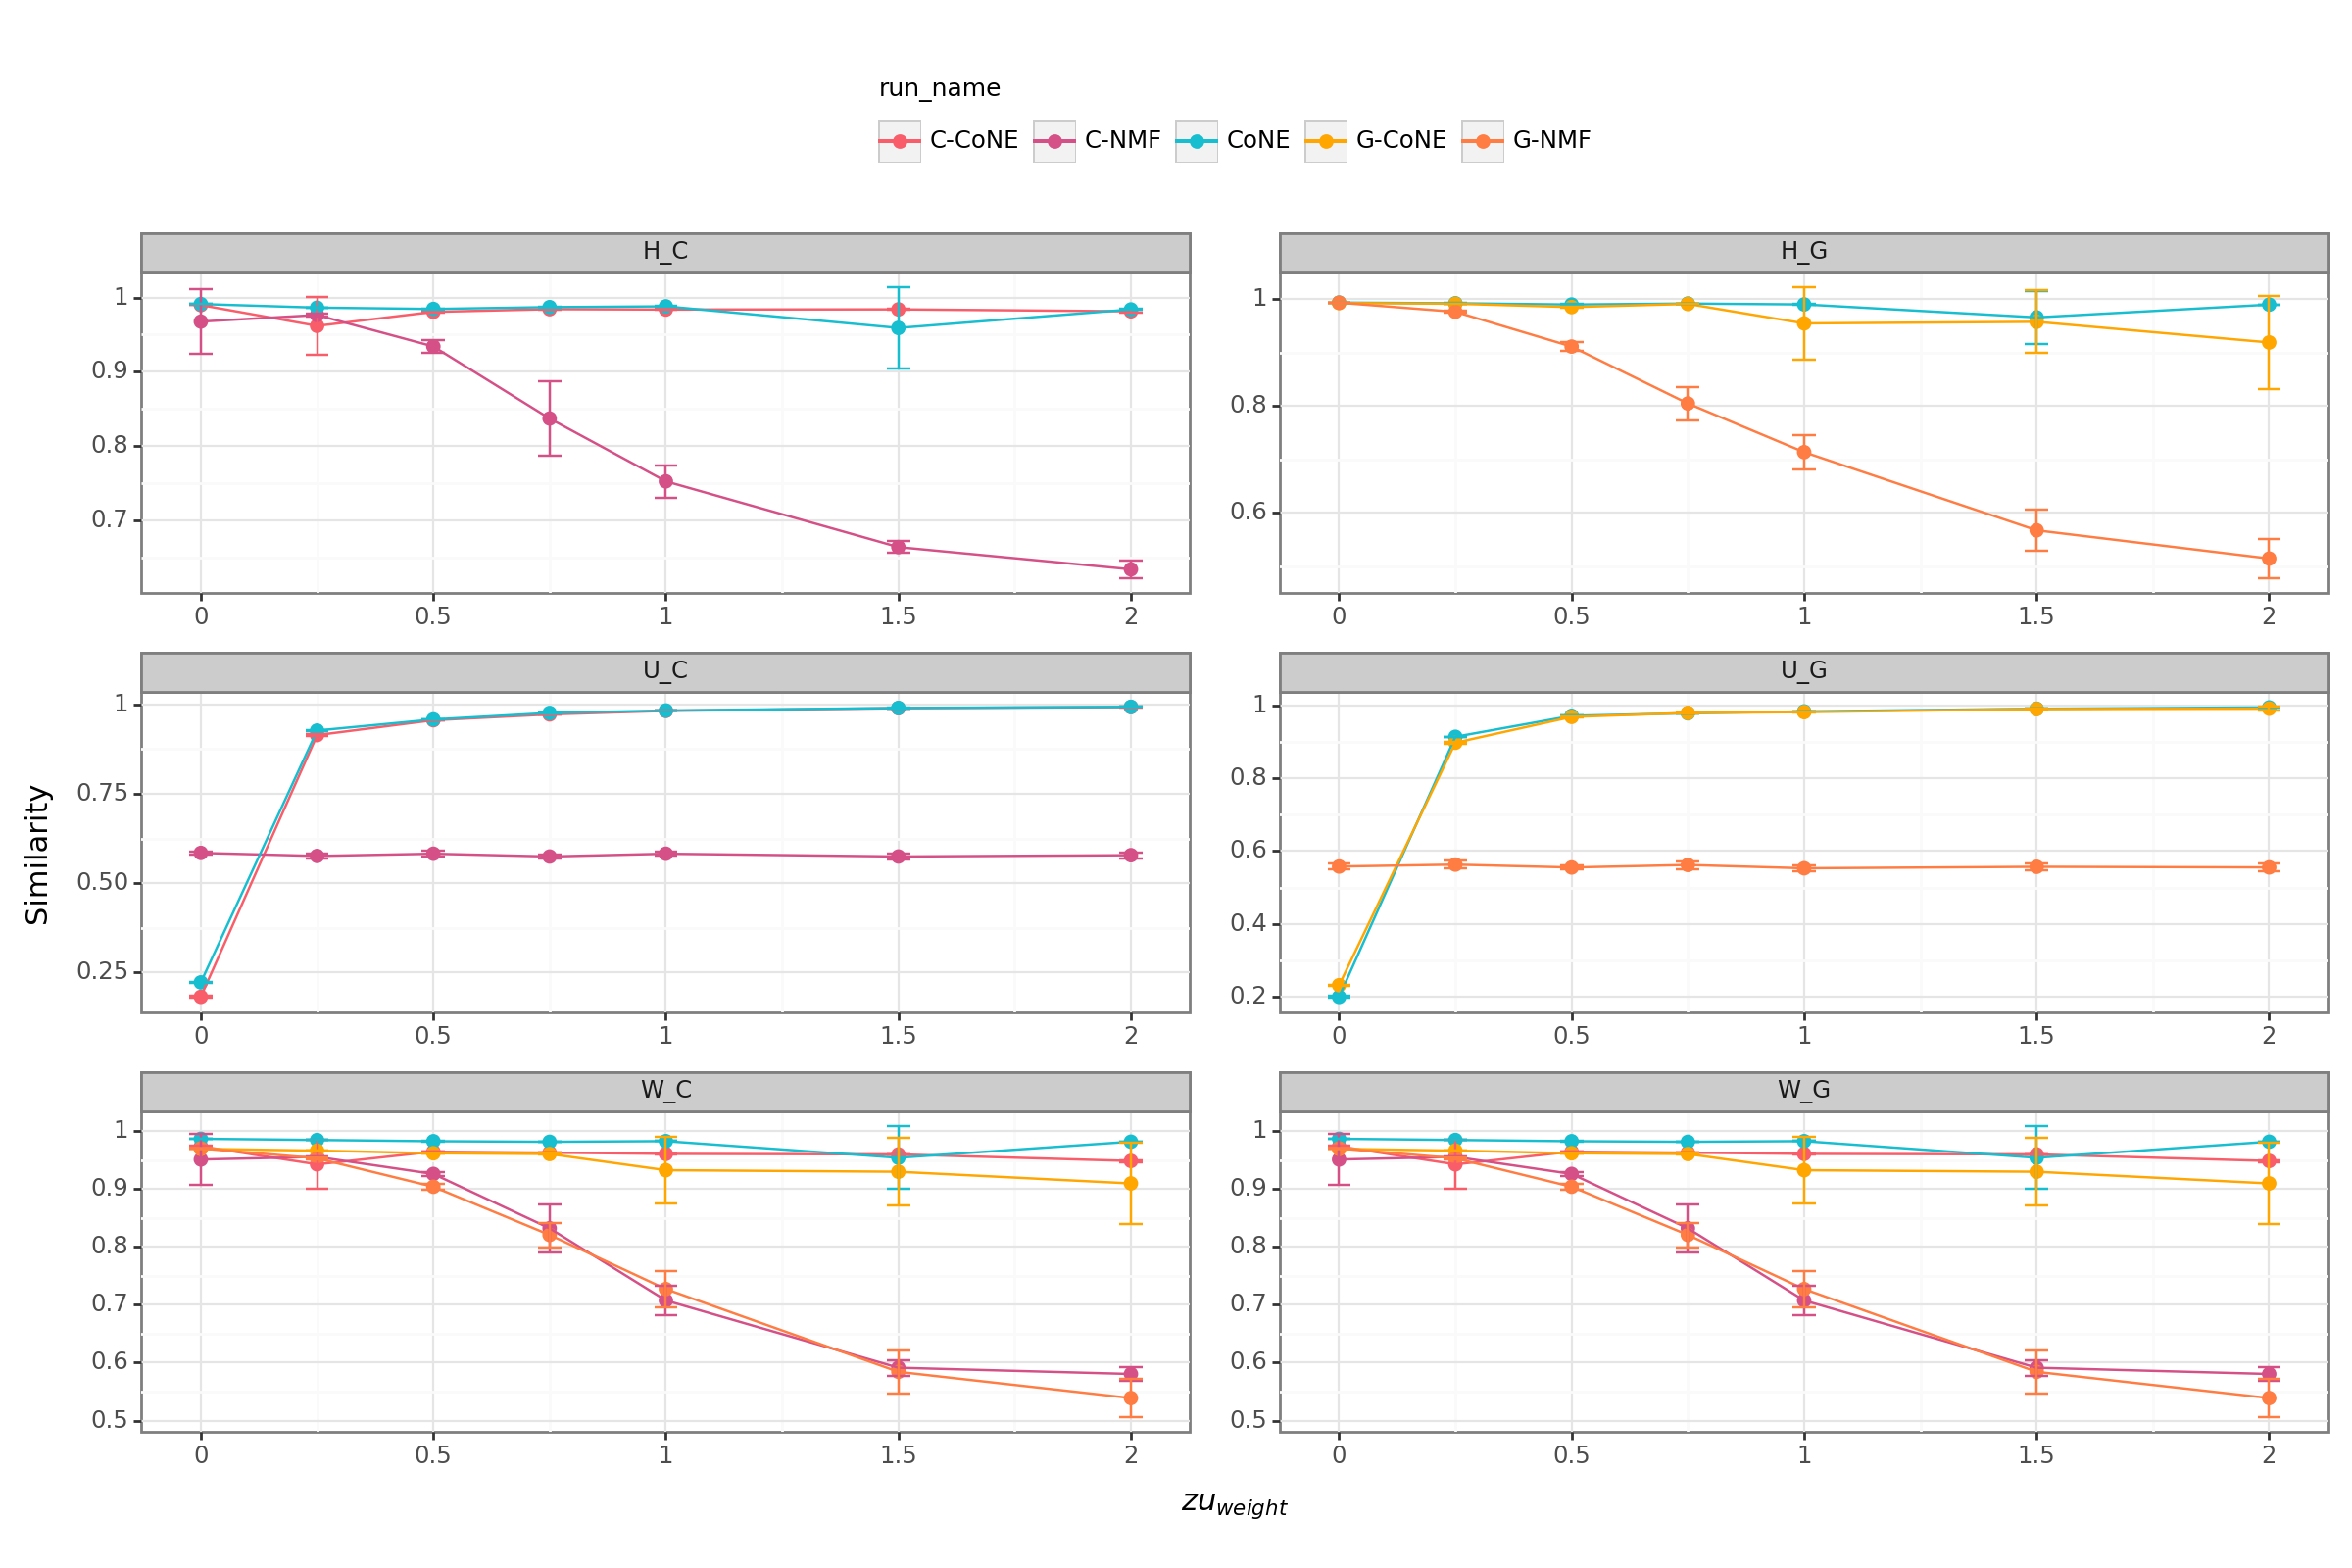

In [ ]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("ZU_weight", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x=r"$zu_{weight}$")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

# Assess runs over noise

In [ ]:
summary = run_one("noise",  np.arange(0,1.1,0.1))


In [ ]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("noise", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x="noise")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

# Assess runs over sparsity

In [ ]:
summary = run_one("sparsity",  np.arange(0,1.1,0.1))
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x="sparsity")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)